In [2]:
import pandas as pd
import numpy as np

customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")

print("Customers:",customers.shape)
print("Orders :",orders.shape)
print("Payments :",payments.shape)

customers.head(5)

Customers: (99441, 5)
Orders : (99441, 8)
Payments : (103886, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
payments.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [5]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
orders['order_purchase_timestamp'].isnull().sum()

np.int64(0)

In [7]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered.shape

(96478, 8)

In [8]:
#Merge orders with customers (to get customer_unique_id)
df = orders_delivered.merge(customers, on = 'customer_id',how = 'left')
df.head()
df[['order_id','customer_id','customer_unique_id','order_purchase_timestamp']].head()

,order_id,customer_id,customer_unique_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39


In [9]:
# Payments can have multiple rows per order (split/installment payments) — sum them first
payments_summed = payments.groupby('order_id')['payment_value'].sum().reset_index()
print("Unique orders with payment info:", payments_summed.shape)

Unique orders with payment info: (99440, 2)


In [10]:
# Merge in the payment totals
df = df.merge(payments_summed, on='order_id', how='left')
print("Final merged shape:", df.shape)
print("Nulls in payment_value:", df['payment_value'].isnull().sum())
df.head()

Final merged shape: (96478, 13)
Nulls in payment_value: 1


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62


In [ ]:
#  Drop the 1 row with missing payment value
df = df[df['payment_value'].notnull()].copy()
print("Shape after dropping null payment:", df.shape)

Shape after dropping null payment: (96477, 13)


In [ ]:
#  Convert timestamp to datetime, define the reference date for Recency
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
reference_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print("Reference date (day after the most recent order in the dataset):", reference_date)

Reference date (day after the most recent order in the dataset): 2018-08-30 15:00:37


In [ ]:
#  Build the RFM table — one row per unique customer
rfm = df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum')
).reset_index()

print("RFM table shape:", rfm.shape)
rfm.describe()

RFM table shape: (93357, 4)


,Recency,Frequency,Monetary
count,93357.000000,93357.000000,93357.000000
mean,237.936673,1.033420,165.198772
std,152.584315,0.209099,226.314579
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.060000
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.560000
max,695.000000,15.000000,13664.080000


In [ ]:
#  Check skew before scaling
from scipy.stats import skew
print("Recency skew:", skew(rfm['Recency']))
print("Frequency skew:", skew(rfm['Frequency']))
print("Monetary skew:", skew(rfm['Monetary']))

Recency skew: 0.4472697933553115
Frequency skew: 11.094918066281778
Monetary skew: 9.210843098696216


In [ ]:
# Log-transform Monetary (and Frequency, since it's also right-skewed) before scaling
# Recency is fairly well-distributed already, left as-is
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])

rfm[['Recency', 'Frequency_log', 'Monetary_log']].describe()

,Recency,Frequency_log,Monetary_log
count,93357.000000,93357.000000,93357.000000
mean,237.936673,0.706198,4.729149
std,152.584315,0.076683,0.808359
min,1.000000,0.693147,2.359910
25%,114.000000,0.693147,4.159820
50%,219.000000,0.693147,4.689327
75%,346.000000,0.693147,5.212542
max,695.000000,2.772589,9.522599


In [21]:
# Scale the 3 features K-Means will actually use
from sklearn.preprocessing import StandardScaler

features = rfm[['Recency', 'Frequency_log', 'Monetary_log']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

print("Scaled shape:", rfm_scaled.shape)
print("Mean (should be ~0):", rfm_scaled.mean(axis=0))
print("Std (should be ~1):", rfm_scaled.std(axis=0))

Scaled shape: (93357, 3)
Mean (should be ~0): [5.63216068e-18 1.59466257e-15 1.61924620e-16]
Std (should be ~1): [1. 1. 1.]


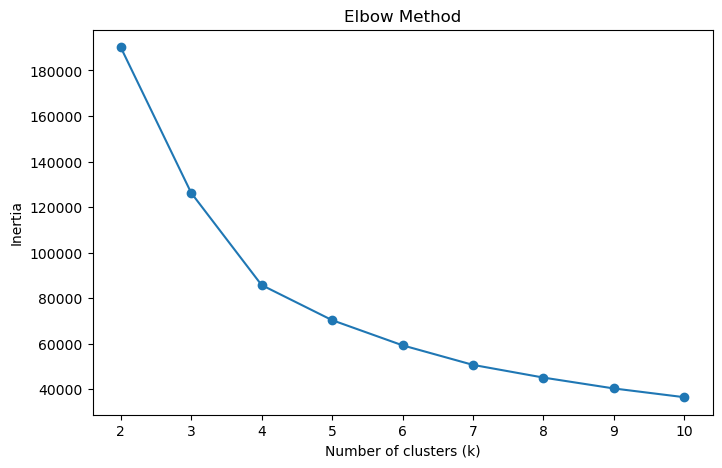

In [ ]:
#  Elbow Method — try k=2 through k=10, record inertia
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

k=2: silhouette score = 0.7082
k=3: silhouette score = 0.3576
k=4: silhouette score = 0.3693
k=5: silhouette score = 0.3530
k=6: silhouette score = 0.3444
k=7: silhouette score = 0.3576
k=8: silhouette score = 0.3482
k=9: silhouette score = 0.3491
k=10: silhouette score = 0.3481


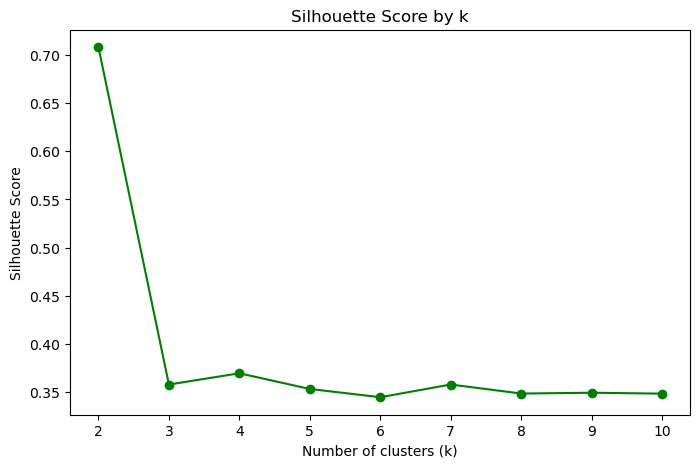

In [24]:
# Silhouette Score for the same range — higher is better, max is 1.0
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.show()

In [25]:
# Cell 16: Profile k=2 — cluster sizes and average R/F/M per cluster
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
rfm['cluster_k2'] = km2.fit_predict(rfm_scaled)

print("k=2 cluster sizes:")
print(rfm['cluster_k2'].value_counts())
print()
print("k=2 cluster profiles (real, unscaled values):")
print(rfm.groupby('cluster_k2')[['Recency', 'Frequency', 'Monetary']].mean())

k=2 cluster sizes:
cluster_k2
1    90556
0     2801
Name: count, dtype: int64

k=2 cluster profiles (real, unscaled values):
               Recency  Frequency    Monetary
cluster_k2                                   
0           220.294538   2.113888  308.588793
1           238.482365   1.000000  160.763556


In [26]:
# Cell 17: Profile k=4 — same thing
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster_k4'] = km4.fit_predict(rfm_scaled)

print("k=4 cluster sizes:")
print(rfm['cluster_k4'].value_counts())
print()
print("k=4 cluster profiles (real, unscaled values):")
print(rfm.groupby('cluster_k4')[['Recency', 'Frequency', 'Monetary']].mean())

k=4 cluster sizes:
cluster_k4
0    35690
3    27856
1    27010
2     2801
Name: count, dtype: int64

k=4 cluster profiles (real, unscaled values):
               Recency  Frequency    Monetary
cluster_k4                                   
0           147.808238   1.000000   69.052519
1           425.363199   1.000000  119.547235
2           220.294538   2.113888  308.588793
3           173.451788   1.000000  318.231237


In [ ]:
# Cell 19: Corrected persona mapping — 1 and 3 were swapped
persona_map = {
    0: 'New / Low-Value',
    1: 'Lapsed / At-Risk',       
    2: 'Loyal Repeat Customers',
    3: 'Recent Big Spenders'      
}
rfm['Persona'] = rfm['cluster_k4'].map(persona_map)
print(rfm['Persona'].value_counts())
print()
print(rfm.groupby('Persona')[['Recency', 'Frequency', 'Monetary']].mean())

Persona
New / Low-Value           35690
Recent Big Spenders       27856
Lapsed / At-Risk          27010
Loyal Repeat Customers     2801
Name: count, dtype: int64

                           Recency  Frequency    Monetary
Persona                                                  
Lapsed / At-Risk        425.363199   1.000000  119.547235
Loyal Repeat Customers  220.294538   2.113888  308.588793
New / Low-Value         147.808238   1.000000   69.052519
Recent Big Spenders     173.451788   1.000000  318.231237


In [29]:
# Cell 20: Save the final RFM + Persona table for PowerBI
rfm_final = rfm[['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'Persona']]
rfm_final.to_csv('customer_segments.csv', index=False)
print("Saved:", rfm_final.shape)
rfm_final.head()

Saved: (93357, 5)


,customer_unique_id,Recency,Frequency,Monetary,Persona
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,Recent Big Spenders
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,New / Low-Value
2,0000f46a3911fa3c0805444483337064,537,1,86.22,Lapsed / At-Risk
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,Lapsed / At-Risk
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,Recent Big Spenders


In [30]:
# Cell 21: Also save a summary table — average RFM per persona, useful for a quick PowerBI KPI view
persona_summary = rfm.groupby('Persona').agg(
    Customer_Count=('customer_unique_id', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()
persona_summary.to_csv('persona_summary.csv', index=False)
persona_summary

,Persona,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,Lapsed / At-Risk,27010,425.363199,1.000000,119.547235
1,Loyal Repeat Customers,2801,220.294538,2.113888,308.588793
2,New / Low-Value,35690,147.808238,1.000000,69.052519
3,Recent Big Spenders,27856,173.451788,1.000000,318.231237


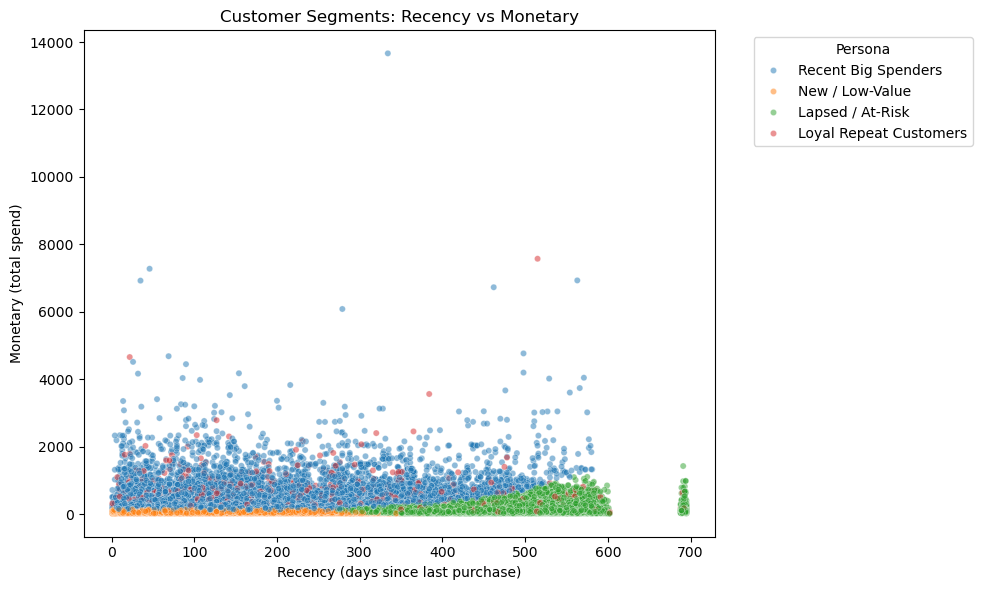

In [34]:
# Cell 22: Scatter plot — Recency vs Monetary, colored by persona
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Persona',
    alpha=0.5,
    s=20
)
plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (total spend)')
plt.legend(title='Persona', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.ylim(0, 1000)         #zoom values for  0-1000 
plt.tight_layout()
plt.show()

C:\Users\uttam prajapat\AppData\Local\Temp\ipykernel_16084\535263014.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=persona_summary_sorted, x='Persona', y='Customer_Count', palette='viridis')


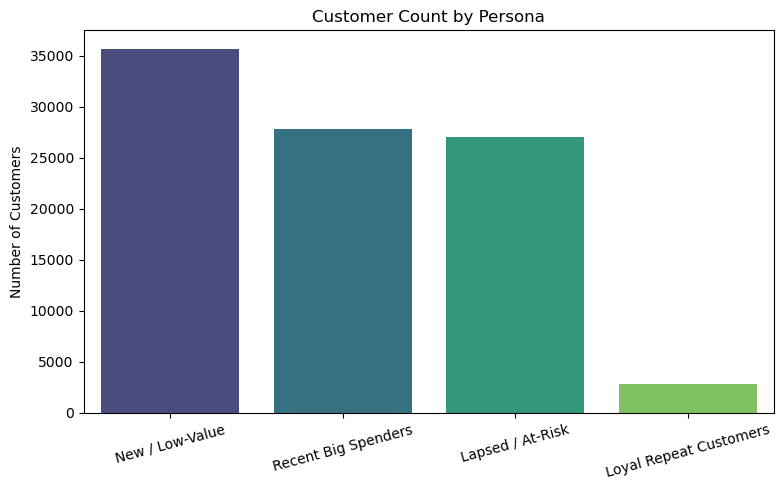

In [35]:
# Cell 23: Bar chart — persona sizes, a clean visual for your README
plt.figure(figsize=(8, 5))
persona_summary_sorted = persona_summary.sort_values('Customer_Count', ascending=False)
sns.barplot(data=persona_summary_sorted, x='Persona', y='Customer_Count', palette='viridis')
plt.title('Customer Count by Persona')
plt.xlabel('')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()